# Analysis of results 

Distribution of scores assigned by Model Gemma3 as Judge when comparing the performance of language model pairs: Llama vs Gemma

By: Gabriela Díaz



## Extreme values analysis 


In [12]:
# Import section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [13]:
###################################
# Colors definition for models
###################################

color_GE_0shot = '#ffac37'
color_GE_1shot = '#ffc575'
# LL '#009e73','#0bd9a1'
color_LL_0shot = '#009e73'
color_LL_1shot = '#0bd9a1'
# DS '#0077bb','#60b8eb'
color_DS_0shot = '#0077bb'
color_DS_1shot = '#60b8eb'
palette_stance_blue =  {"favor": "#1F4BE6", "against": "#023BD3", "polarized": "#9FB2F5"} #blue
palette_stance_orange =  {"favor": "#e67e22", "against": "#d35400", "polarized": "#f5cba7"} #orange
palette_stance_green = {"favor": "#2ecc71", "against": "#27ae60", "polarized": "#a3e4d7"} #green

color_title_green="#196f3d"
color_title_orange = "#7e5109"
color_title_blue = "#0F4ABD"


In [14]:
# =============================================================================
# CONFIGURATION 
#  Change next variables to compare different models. 
# =============================================================================

# filename 
filename_scores = 'jllama_ll_ge.csv' #this file contain scores for the two models that are compared. 
filename_output = '_ll_vs_ge_'

# Model names for labeling
model1_name = 'Llama'
model2_name = 'Gemma'

# Column mappings - change these to match your data structure
score1_col = 'score1'  # Column name for model 1 scores
score2_col = 'score2'  # Column name for model 2 scores
arg1_col = 'arg1'      # Column name for model 1 arguments
arg2_col = 'arg2'      # Column name for model 2 arguments

# Other column names
color_col = 'color'
stance_col = 'stance'

# Colors
palette_colors = [color_LL_1shot,color_GE_1shot]

# Colors for the last violin
pallete_stance_model1 = palette_stance_green
pallete_stance_model2 = palette_stance_orange 
color_title_model1 = color_title_green
color_title_model2 = color_title_orange

df = pd.read_csv(filename_scores)

#drop Nan in score1 or score2 
df = df.dropna(subset=['score1', 'score2'], how='any')

In [15]:
print(f"=== {model1_name.upper()} vs {model2_name.upper()} COMPARISON BY STANCE AND MODEL ===\n")

# Display sample of the data
print("DATA OVERVIEW:")
print(f"Total topics analyzed: {len(df)}")
print(f"Stance distribution: {df[stance_col].value_counts().to_dict()}")
print(f"Color range: {df[color_col].min():.3f} to {df[color_col].max():.3f}")
print(f"Models being compared: {model1_name} vs {model2_name}")
print()

# Basic statistics by model
print("=== MODEL COMPARISON ===")
print("OVERALL MODEL PERFORMANCE:")
print(f"{model1_name} - Mean: {df[score1_col].mean():.2f}, Std: {df[score1_col].std():.2f}")
print(f"{model2_name} - Mean: {df[score2_col].mean():.2f}, Std: {df[score2_col].std():.2f}")

# Statistical test between models
t_stat, p_value = stats.ttest_rel(df[score1_col], df[score2_col])
print(f"\nPaired t-test between models:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

# Model wins
model1_wins = (df[score1_col] > df[score2_col]).sum()
model2_wins = (df[score2_col] > df[score1_col]).sum()
ties = (df[score1_col] == df[score2_col]).sum()

print(f"\nHead-to-head comparison:")
print(f"  {model1_name} wins: {model1_wins} topics")
print(f"  {model2_name} wins: {model2_wins} topics")
print(f"  Ties: {ties} topics")
print()

# Analysis by stance
print("=== ANALYSIS BY STANCE ===")
print("PERFORMANCE BY STANCE:")
for stance in df[stance_col].unique():
    stance_data = df[df[stance_col] == stance]
    print(f"\n{stance.upper()} topics ({len(stance_data)} topics):")
    print(f"  Average color value: {stance_data[color_col].mean():.3f}")
    print(f"  {model1_name} - Mean: {stance_data[score1_col].mean():.2f}, Std: {stance_data[score1_col].std():.2f}")
    print(f"  {model2_name} - Mean: {stance_data[score2_col].mean():.2f}, Std: {stance_data[score2_col].std():.2f}")
    
    # Model comparison within this stance
    m1_wins = (stance_data[score1_col] > stance_data[score2_col]).sum()
    m2_wins = (stance_data[score2_col] > stance_data[score1_col]).sum()
    ties = (stance_data[score1_col] == stance_data[score2_col]).sum()
    print(f"  Within {stance}: {model1_name} wins {m1_wins}, {model2_name} wins {m2_wins}, Ties {ties}")

print()

# Color-based analysis (opinion distribution)
print("=== COLOR-BASED ANALYSIS (OPINION DISTRIBUTION) ===")
def categorize_color(color_val):
    if color_val < 0.33:
        return 'denier_heavy'  # Red zone
    elif color_val > 0.67:
        return 'believer_heavy'  # Green zone
    else:
        return 'balanced'  # Yellow zone (polarized)

df['color_category'] = df[color_col].apply(categorize_color)

print("PERFORMANCE BY OPINION DISTRIBUTION:")
for category in ['denier_heavy', 'balanced', 'believer_heavy']:
    cat_data = df[df['color_category'] == category]
    if len(cat_data) > 0:
        color_range = f"{cat_data[color_col].min():.3f}-{cat_data[color_col].max():.3f}"
        print(f"\n{category.upper().replace('_', ' ')} topics ({len(cat_data)} topics, color: {color_range}):")
        print(f"  {model1_name} avg: {cat_data[score1_col].mean():.2f}")
        print(f"  {model2_name} avg: {cat_data[score2_col].mean():.2f}")
        
        m1_wins = (cat_data[score1_col] > cat_data[score2_col]).sum()
        m2_wins = (cat_data[score2_col] > cat_data[score1_col]).sum()
        ties = (cat_data[score1_col] == cat_data[score2_col]).sum()
        print(f"  Model performance: {model1_name} wins {m1_wins}, {model2_name} wins {m2_wins}, Ties {ties}")

print()

=== LLAMA vs GEMMA COMPARISON BY STANCE AND MODEL ===

DATA OVERVIEW:
Total topics analyzed: 2349
Stance distribution: {'favor': 2194, 'against': 113, 'polarized': 42}
Color range: 0.000 to 1.000
Models being compared: Llama vs Gemma

=== MODEL COMPARISON ===
OVERALL MODEL PERFORMANCE:
Llama - Mean: 4.58, Std: 0.79
Gemma - Mean: 3.12, Std: 1.07

Paired t-test between models:
  T-statistic: 51.8653
  P-value: 0.0000
  Significant difference: Yes

Head-to-head comparison:
  Llama wins: 2057 topics
  Gemma wins: 206 topics
  Ties: 86 topics

=== ANALYSIS BY STANCE ===
PERFORMANCE BY STANCE:

FAVOR topics (2194 topics):
  Average color value: 0.965
  Llama - Mean: 4.62, Std: 0.74
  Gemma - Mean: 3.15, Std: 1.07
  Within favor: Llama wins 1931, Gemma wins 179, Ties 84

POLARIZED topics (42 topics):
  Average color value: 0.523
  Llama - Mean: 3.52, Std: 1.23
  Gemma - Mean: 2.67, Std: 0.98
  Within polarized: Llama wins 32, Gemma wins 9, Ties 1

AGAINST topics (113 topics):
  Average color 

In [16]:
# Find extreme cases
print("=== EXTREME CASES ANALYSIS ===")

# Lowest scores
min_score = min(df[score1_col].min(), df[score2_col].min())
print(f"LOWEST SCORE FOUND: {min_score}")

min_score1_rows = df[df[score1_col] == min_score]
min_score2_rows = df[df[score2_col] == min_score]

if not min_score1_rows.empty:
    print(f"\n{model1_name} lowest scores:")
    for idx, row in min_score1_rows.iterrows():
        color_desc = "red" if row[color_col] < 0.33 else "green" if row[color_col] > 0.67 else "yellow"
        print(f"  Topic {idx}: stance='{row[stance_col]}', color={row[color_col]:.3f}({color_desc})")
        print(f"    {arg1_col}='{row[arg1_col]}', {model1_name} score={row[score1_col]}")
        print(f"    {arg2_col}='{row[arg2_col]}', {model2_name} score={row[score2_col]}")

if not min_score2_rows.empty:
    print(f"\n{model2_name} lowest scores:")
    for idx, row in min_score2_rows.iterrows():
        color_desc = "red" if row[color_col] < 0.33 else "green" if row[color_col] > 0.67 else "yellow"
        print(f"  Topic {idx}: stance='{row[stance_col]}', color={row[color_col]:.3f}({color_desc})")
        print(f"    {arg1_col}='{row[arg1_col]}', {model1_name} score={row[score1_col]}")
        print(f"    {arg2_col}='{row[arg2_col]}', {model2_name} score={row[score2_col]}")

=== EXTREME CASES ANALYSIS ===
LOWEST SCORE FOUND: 1.0

Llama lowest scores:
  Topic 59: stance='favor', color=0.905(green)
    arg1='Could not extract valid JSON from the input 2', Llama score=1.0
    arg2='It is observed that a significant impact is being exerted by China's actions, with a clear examination of the global supply chain and air pollution being presented. Concerns are being raised regarding the frequency of attacks by China since WWII, and the refusal of the US to comply with global efforts on climate change. It is recognized that air pollution is being presented as a potential solution to climate change, and that the consequences of China's actions are being scrutinized on a global scale.', Gemma score=2.0
  Topic 103: stance='favor', color=0.993(green)
    arg1='Could not extract valid JSON from the input 2', Llama score=1.0
    arg2='It is observed that concerns regarding the extent of climate change are being raised, with questions being directed towards the actions 

In [17]:
# Highest scores
max_score = max(df[score1_col].max(), df[score2_col].max())
print(f"\nHIGHEST SCORE FOUND: {max_score}")

max_score1_rows = df[df[score1_col] == max_score]
max_score2_rows = df[df[score2_col] == max_score]

if not max_score1_rows.empty:
    print(f"\n{model1_name} highest scores:")
    for idx, row in max_score1_rows.iterrows():
        color_desc = "red" if row[color_col] < 0.33 else "green" if row[color_col] > 0.67 else "yellow"
        print(f"  Topic {idx}: stance='{row[stance_col]}', color={row[color_col]:.3f}({color_desc})")
        print(f"    {arg1_col}='{row[arg1_col]}', {model1_name} score={row[score1_col]}")
        print(f"    {arg2_col}='{row[arg2_col]}', {model2_name} score={row[score2_col]}")

if not max_score2_rows.empty:
    print(f"\n{model2_name} highest scores:")
    for idx, row in max_score2_rows.iterrows():
        color_desc = "red" if row[color_col] < 0.33 else "green" if row[color_col] > 0.67 else "yellow"
        print(f"  Topic {idx}: stance='{row[stance_col]}', color={row[color_col]:.3f}({color_desc})")
        print(f"    {arg1_col}='{row[arg1_col]}', {model1_name} score={row[score1_col]}")
        print(f"    {arg2_col}='{row[arg2_col]}', {model2_name} score={row[score2_col]}")

print()


HIGHEST SCORE FOUND: 5.0

Llama highest scores:
  Topic 0: stance='favor', color=0.997(green)
    arg1='It is widely acknowledged that climate change has become a pressing issue, with various political figures recognizing its importance and committing to combat it. The increasing attention on this topic is seen as a positive development, as it brings together individuals who share similar concerns about the future of our planet. It is urged that these leaders continue to prioritize climate change as a key aspect of their platforms, in order to inspire a broader movement towards sustainability and environmental protection.', Llama score=5.0
    arg2='It is observed that a significant number of candidates are being positioned as committed to combating climate change, and a considerable effort is being directed towards framing this issue as a central priority.  The idea of candidates being targeted for their stances on this matter is being actively promoted, suggesting a widespread recog

In [18]:
# Cross-tabulation analysis
print("=== CROSS-TABULATION ANALYSIS ===")
print("STANCE vs COLOR CATEGORY:")
cross_tab = pd.crosstab(df[stance_col], df['color_category'])
print(cross_tab)
print()

# Performance matrix
print("AVERAGE SCORES BY STANCE AND COLOR CATEGORY:")
pivot_score1 = df.pivot_table(values=score1_col, index=stance_col, columns='color_category', aggfunc='mean')
pivot_score2 = df.pivot_table(values=score2_col, index=stance_col, columns='color_category', aggfunc='mean')

print(f"\n{model1_name} averages:")
print(pivot_score1.fillna('N/A').round(2))
print(f"\n{model2_name} averages:")
print(pivot_score2.fillna('N/A').round(2))

=== CROSS-TABULATION ANALYSIS ===
STANCE vs COLOR CATEGORY:
color_category  balanced  believer_heavy  denier_heavy
stance                                                
against               17               0            96
favor                 20            2174             0
polarized             42               0             0

AVERAGE SCORES BY STANCE AND COLOR CATEGORY:

Llama averages:
color_category  balanced believer_heavy denier_heavy
stance                                              
against             3.94            N/A       4.1875
favor               4.15       4.627875          N/A
polarized           3.52            N/A          N/A

Gemma averages:
color_category  balanced believer_heavy denier_heavy
stance                                              
against             2.94            N/A     2.822917
favor               3.15       3.148114          N/A
polarized           2.67            N/A          N/A



=== CREATING VISUALIZATIONS ===


/tmp/ipykernel_1361347/1169726615.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  color_perf = df.groupby('color_bin')[[score1_col, score2_col]].mean()


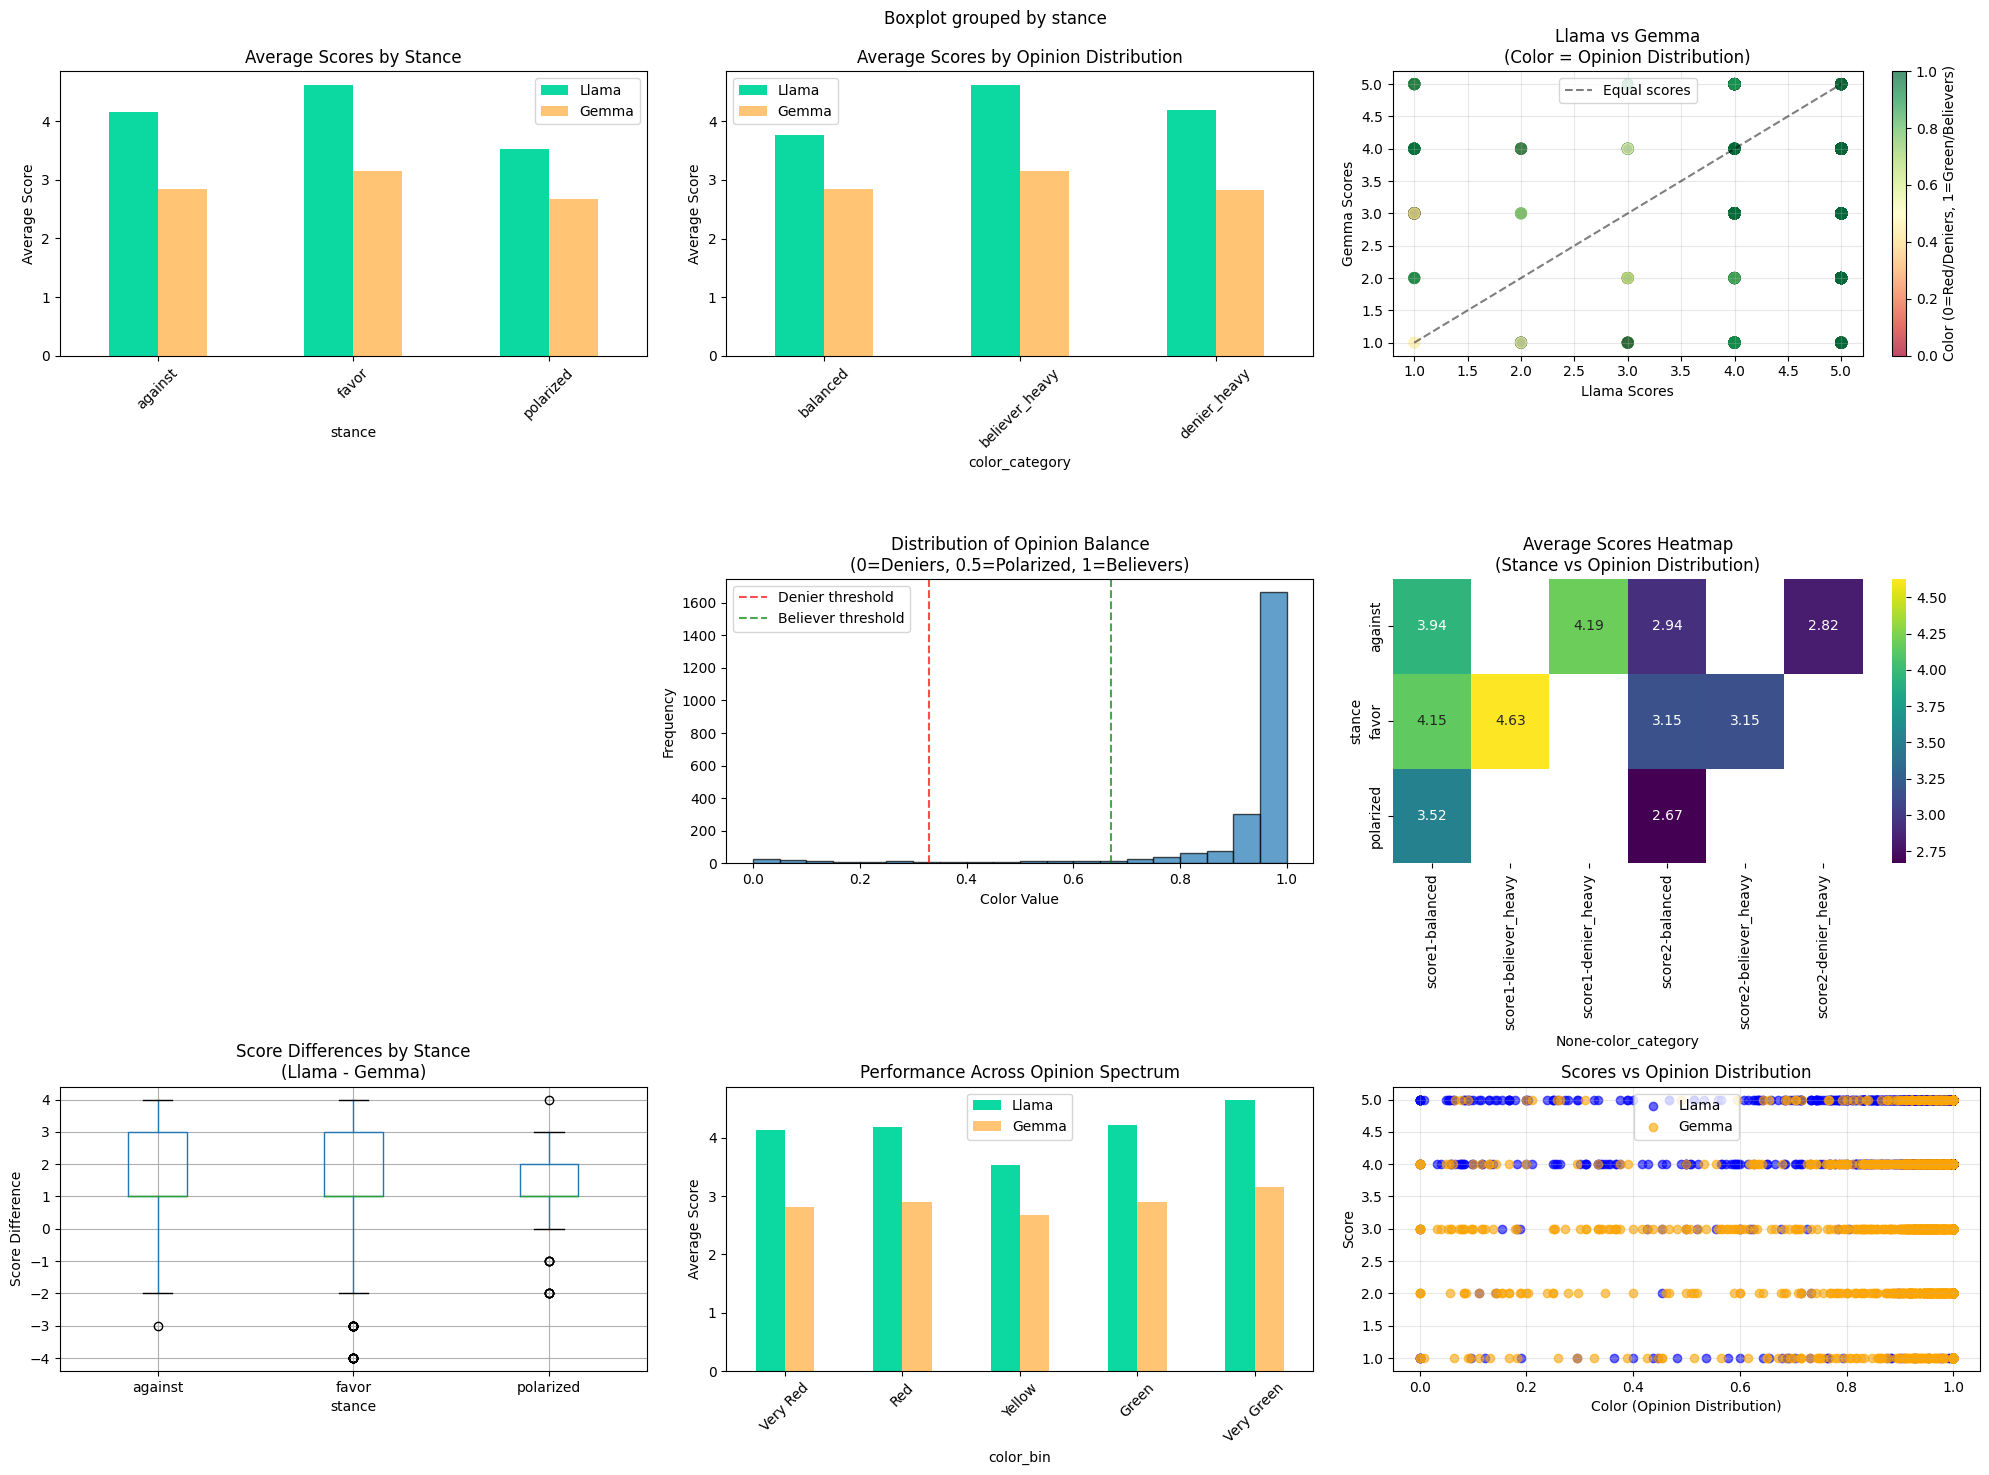

In [19]:
# Create comprehensive visualizations
print("\n=== CREATING VISUALIZATIONS ===")
fig = plt.figure(figsize=(20, 15))

# 1. Score distribution by stance
ax1 = plt.subplot(3, 3, 1)
stance_means = df.groupby(stance_col)[[score1_col, score2_col]].mean()
stance_means.plot(kind='bar', ax=ax1, color=palette_colors)
ax1.set_title('Average Scores by Stance')
ax1.set_ylabel('Average Score')
ax1.legend([model1_name, model2_name])
ax1.tick_params(axis='x', rotation=45)

# 2. Score distribution by color category
ax2 = plt.subplot(3, 3, 2)
color_means = df.groupby('color_category')[[score1_col, score2_col]].mean()
color_means.plot(kind='bar', ax=ax2, color=palette_colors)
ax2.set_title('Average Scores by Opinion Distribution')
ax2.set_ylabel('Average Score')
ax2.legend([model1_name, model2_name])
ax2.tick_params(axis='x', rotation=45)

# 3. Scatter plot with color coding
ax3 = plt.subplot(3, 3, 3)
scatter = ax3.scatter(df[score1_col], df[score2_col], c=df[color_col], cmap='RdYlGn', alpha=0.7, s=60)
ax3.plot([1, 5], [1, 5], 'k--', alpha=0.5, label='Equal scores')
ax3.set_xlabel(f'{model1_name} Scores')
ax3.set_ylabel(f'{model2_name} Scores')
ax3.set_title(f'{model1_name} vs {model2_name}\n(Color = Opinion Distribution)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Color (0=Red/Deniers, 1=Green/Believers)')

# 4. Box plots by stance
#ax4 = plt.subplot(3, 3, 4)
#df.boxplot(column=[score1_col, score2_col], by=stance_col, ax=ax4)
#ax4.set_title('Score Distribution by Stance')
#ax4.set_ylabel('Score')

# 5. Color distribution histogram
ax5 = plt.subplot(3, 3, 5)
ax5.hist(df[color_col], bins=20, alpha=0.7, edgecolor='black')
ax5.set_xlabel('Color Value')
ax5.set_ylabel('Frequency')
ax5.set_title('Distribution of Opinion Balance\n(0=Deniers, 0.5=Polarized, 1=Believers)')
ax5.axvline(x=0.33, color='red', linestyle='--', alpha=0.7, label='Denier threshold')
ax5.axvline(x=0.67, color='green', linestyle='--', alpha=0.7, label='Believer threshold')
ax5.legend()

# 6. Heatmap of average scores
ax6 = plt.subplot(3, 3, 6)
heatmap_data = df.pivot_table(values=[score1_col, score2_col], index=stance_col, columns='color_category', aggfunc='mean')
if not heatmap_data.empty:
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', ax=ax6, fmt='.2f')
    ax6.set_title('Average Scores Heatmap\n(Stance vs Opinion Distribution)')

# 7. Difference analysis by stance
ax7 = plt.subplot(3, 3, 7)
df['score_diff'] = df[score1_col] - df[score2_col]
df.boxplot(column='score_diff', by=stance_col, ax=ax7)
ax7.set_title(f'Score Differences by Stance\n({model1_name} - {model2_name})')
ax7.set_ylabel('Score Difference')

# 8. Model performance by color
ax8 = plt.subplot(3, 3, 8)
# Create bins for color analysis
df['color_bin'] = pd.cut(df[color_col], bins=5, labels=['Very Red', 'Red', 'Yellow', 'Green', 'Very Green'])
color_perf = df.groupby('color_bin')[[score1_col, score2_col]].mean()
color_perf.plot(kind='bar', ax=ax8, color=palette_colors)
ax8.set_title('Performance Across Opinion Spectrum')
ax8.set_ylabel('Average Score')
ax8.legend([model1_name, model2_name])
ax8.tick_params(axis='x', rotation=45)

# 9. Correlation analysis
ax9 = plt.subplot(3, 3, 9)
ax9.scatter(df[color_col], df[score1_col], alpha=0.6, label=model1_name, color='blue')
ax9.scatter(df[color_col], df[score2_col], alpha=0.6, label=model2_name, color='orange')
ax9.set_xlabel('Color (Opinion Distribution)')
ax9.set_ylabel('Score')
ax9.set_title('Scores vs Opinion Distribution')
ax9.legend()
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Detailed analysis
print("\n=== DETAILED ANALYSIS ===")

# Correlation between color and scores
corr_color_score1 = df[color_col].corr(df[score1_col])
corr_color_score2 = df[color_col].corr(df[score2_col])

print("CORRELATION ANALYSIS:")
print(f"Color vs {model1_name} scores: {corr_color_score1:.4f}")
print(f"Color vs {model2_name} scores: {corr_color_score2:.4f}")
print(f"{model1_name} vs {model2_name} scores: {df[score1_col].corr(df[score2_col]):.4f}")
print()

# Performance in different opinion environments
print("MODEL PERFORMANCE IN DIFFERENT OPINION ENVIRONMENTS:")
for category, desc in [('denier_heavy', 'Denier-heavy topics (Red zone)'),
                       ('balanced', 'Polarized topics (Yellow zone)'),
                       ('believer_heavy', 'Believer-heavy topics (Green zone)')]:
    cat_data = df[df['color_category'] == category]
    if len(cat_data) > 0:
        print(f"\n{desc}:")
        print(f"  Topics: {len(cat_data)}")
        print(f"  {model1_name} avg: {cat_data[score1_col].mean():.2f}")
        print(f"  {model2_name} avg: {cat_data[score2_col].mean():.2f}")
        
        # Test if there's a significant difference between models in this category
        if len(cat_data) > 1:
            t_stat_cat, p_val_cat = stats.ttest_rel(cat_data[score1_col], cat_data[score2_col])
            print(f"  Significant difference between models: {'Yes' if p_val_cat < 0.05 else 'No'} (p={p_val_cat:.4f})")

# Best and worst performing topics
print(f"\n=== BEST AND WORST PERFORMING TOPICS ===")

# Best Model 1 performance
best_m1 = df.loc[df[score1_col].idxmax()]
print(f"BEST {model1_name} performance (Score: {best_m1[score1_col]}):")
color_desc = "red" if best_m1[color_col] < 0.33 else "green" if best_m1[color_col] > 0.67 else "yellow"
print(f"  Topic: stance='{best_m1[stance_col]}', color={best_m1[color_col]:.3f}({color_desc})")
print(f"  {arg1_col}='{best_m1[arg1_col]}', {model1_name} score={best_m1[score1_col]}")
print(f"  {arg2_col}='{best_m1[arg2_col]}', {model2_name} score={best_m1[score2_col]}")

# Worst Model 1 performance
worst_m1 = df.loc[df[score1_col].idxmin()]
print(f"\nWORST {model1_name} performance (Score: {worst_m1[score1_col]}):")
color_desc = "red" if worst_m1[color_col] < 0.33 else "green" if worst_m1[color_col] > 0.67 else "yellow"
print(f"  Topic: stance='{worst_m1[stance_col]}', color={worst_m1[color_col]:.3f}({color_desc})")
print(f"  {arg1_col}='{worst_m1[arg1_col]}', {model1_name} score={worst_m1[score1_col]}")
print(f"  {arg2_col}='{worst_m1[arg2_col]}', {model2_name} score={worst_m1[score2_col]}")

# Best Model 2 performance
best_m2 = df.loc[df[score2_col].idxmax()]
print(f"\nBEST {model2_name} performance (Score: {best_m2[score2_col]}):")
color_desc = "red" if best_m2[color_col] < 0.33 else "green" if best_m2[color_col] > 0.67 else "yellow"
print(f"  Topic: stance='{best_m2[stance_col]}', color={best_m2[color_col]:.3f}({color_desc})")
print(f"  {arg1_col}='{best_m2[arg1_col]}', {model1_name} score={best_m2[score1_col]}")
print(f"  {arg2_col}='{best_m2[arg2_col]}', {model2_name} score={best_m2[score2_col]}")

# Worst Model 2 performance
worst_m2 = df.loc[df[score2_col].idxmin()]
print(f"\nWORST {model2_name} performance (Score: {worst_m2[score2_col]}):")
color_desc = "red" if worst_m2[color_col] < 0.33 else "green" if worst_m2[color_col] > 0.67 else "yellow"
print(f"  Topic: stance='{worst_m2[stance_col]}', color={worst_m2[color_col]:.3f}({color_desc})")
print(f"  {arg1_col}='{worst_m2[arg1_col]}', {model1_name} score={worst_m2[score1_col]}")
print(f"  {arg2_col}='{worst_m2[arg2_col]}', {model2_name} score={worst_m2[score2_col]}")

# Summary insights
print(f"\n=== KEY INSIGHTS ===")
print("STANCE-BASED INSIGHTS:")
stance_summary = df.groupby(stance_col)[[score1_col, score2_col]].mean()
best_stance_m1 = stance_summary[score1_col].idxmax()
best_stance_m2 = stance_summary[score2_col].idxmax()
print(f"  {model1_name} performs best on '{best_stance_m1}' topics")
print(f"  {model2_name} performs best on '{best_stance_m2}' topics")

print("\nOPINION DISTRIBUTION INSIGHTS:")
color_summary = df.groupby('color_category')[[score1_col, score2_col]].mean()
if not color_summary.empty:
    best_color_m1 = color_summary[score1_col].idxmax() if len(color_summary) > 0 else 'N/A'
    best_color_m2 = color_summary[score2_col].idxmax() if len(color_summary) > 0 else 'N/A'
    print(f"  {model1_name} performs best in '{best_color_m1}' opinion environments")
    print(f"  {model2_name} performs best in '{best_color_m2}' opinion environments")

# Overall winner
if df[score1_col].mean() > df[score2_col].mean():
    overall_better = model1_name
    diff = df[score1_col].mean() - df[score2_col].mean()
elif df[score2_col].mean() > df[score1_col].mean():
    overall_better = model2_name
    diff = df[score2_col].mean() - df[score1_col].mean()
else:
    overall_better = "Tie"
    diff = 0

print(f"\nOVERALL BETTER MODEL: {overall_better}")
if diff > 0:
    print(f"  Average advantage: {diff:.3f} points")




=== DETAILED ANALYSIS ===
CORRELATION ANALYSIS:
Color vs Llama scores: 0.2032
Color vs Gemma scores: 0.0973
Llama vs Gemma scores: -0.0448

MODEL PERFORMANCE IN DIFFERENT OPINION ENVIRONMENTS:

Denier-heavy topics (Red zone):
  Topics: 96
  Llama avg: 4.19
  Gemma avg: 2.82
  Significant difference between models: Yes (p=0.0000)

Polarized topics (Yellow zone):
  Topics: 79
  Llama avg: 3.77
  Gemma avg: 2.85
  Significant difference between models: Yes (p=0.0000)

Believer-heavy topics (Green zone):
  Topics: 2174
  Llama avg: 4.63
  Gemma avg: 3.15
  Significant difference between models: Yes (p=0.0000)

=== BEST AND WORST PERFORMING TOPICS ===
BEST Llama performance (Score: 5.0):
  Topic: stance='favor', color=0.997(green)
  arg1='It is widely acknowledged that climate change has become a pressing issue, with various political figures recognizing its importance and committing to combat it. The increasing attention on this topic is seen as a positive development, as it brings togeth

## Violin Plot

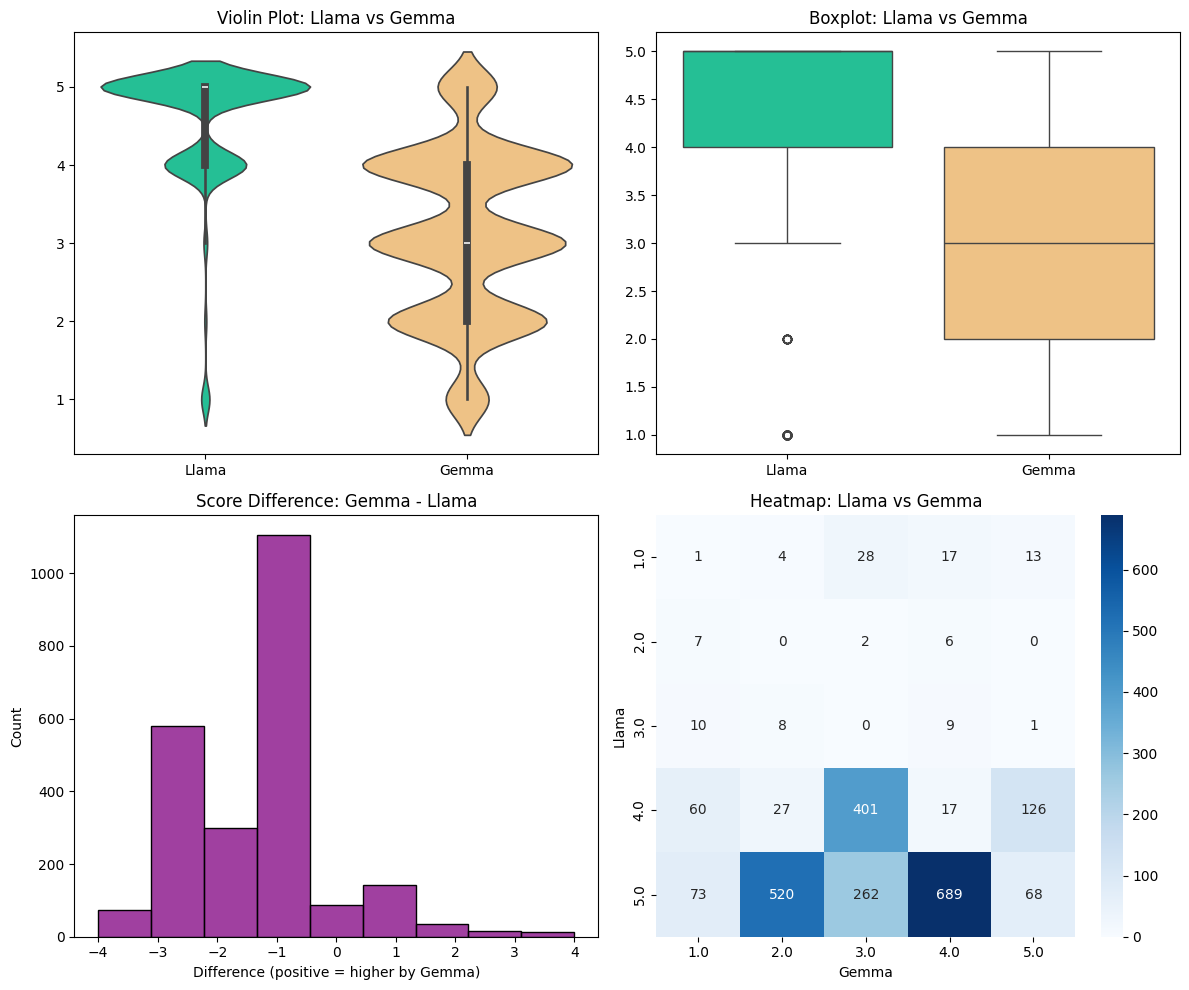

In [21]:




# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Violin plot
sns.violinplot(
    data=df[[score1_col, score2_col]].rename(
        columns={score1_col: model1_name, score2_col: model2_name}
    ),
    ax=axes[0,0],
    palette=palette_colors
)
axes[0,0].set_title(f"Violin Plot: {model1_name} vs {model2_name}")

# Boxplot
sns.boxplot(
    data=df[[score1_col, score2_col]].rename(
        columns={score1_col: model1_name, score2_col: model2_name}
    ),
    ax=axes[0,1],
    palette=palette_colors
)
axes[0,1].set_title(f"Boxplot: {model1_name} vs {model2_name}")

# 3. Difference distribution (instead of hexbin)
diff = df[score2_col] - df[score1_col]
sns.histplot(diff, bins=9, kde=False, ax=axes[1,0], color="purple")
axes[1,0].set_title(f"Score Difference: {model2_name} - {model1_name}")
axes[1,0].set_xlabel("Difference (positive = higher by " + model2_name + ")")
axes[1,0].set_ylabel("Count")


# Heatmap of agreement
conf_matrix = pd.crosstab(df[score1_col], df[score2_col])
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", ax=axes[1,1])
axes[1,1].set_title(f"Heatmap: {model1_name} vs {model2_name}")
axes[1,1].set_xlabel(model2_name)
axes[1,1].set_ylabel(model1_name)

plt.tight_layout()
#plt.show()
plt.savefig(f'dashboard_{filename_output}.pdf', dpi=300, bbox_inches='tight')

## Dashboard 
 1. Violin plot considering all the scores by stance.
 2. Boxplot considering all the scores by stance.
 3. Difference distribution.
 4. Heatmap (agreement)
 5. Violin plot model 1 by stance.
 6. Violin plot model 2 by stance. 

/tmp/ipykernel_1361347/2608110707.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1361347/2608110707.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


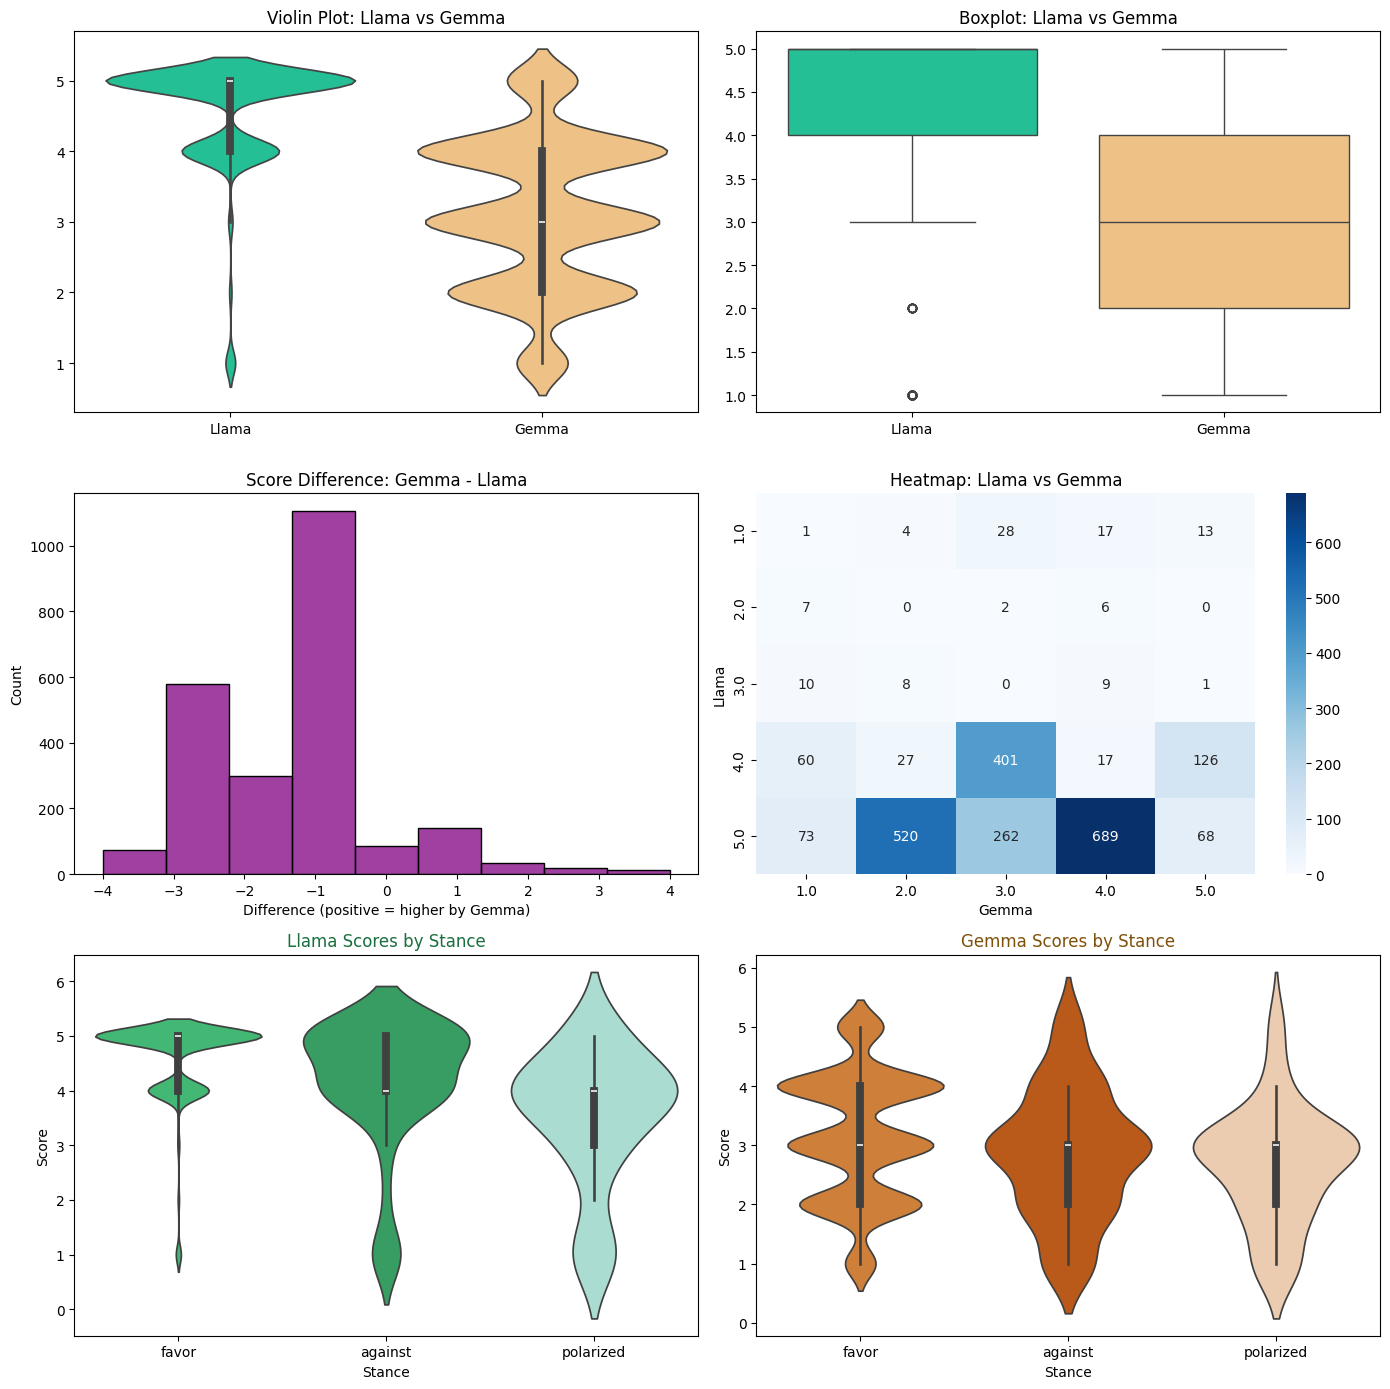

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# --- Visualization ---
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# --- Row 1 ---
# 1. Violin plot (overall)
sns.violinplot(
    data=df[[score1_col, score2_col]].rename(
        columns={score1_col: model1_name, score2_col: model2_name}
    ),
    ax=axes[0,0],
    palette=palette_colors
)
axes[0,0].set_title(f"Violin Plot: {model1_name} vs {model2_name}")

# 2. Boxplot (overall)
sns.boxplot(
    data=df[[score1_col, score2_col]].rename(
        columns={score1_col: model1_name, score2_col: model2_name}
    ),
    ax=axes[0,1],
    palette=palette_colors
)
axes[0,1].set_title(f"Boxplot: {model1_name} vs {model2_name}")

# --- Row 2 ---
# 3. Difference distribution
df["diff"] = df[score2_col] - df[score1_col]
sns.histplot(df["diff"], bins=9, kde=False, ax=axes[1,0], color="purple")
axes[1,0].set_title(f"Score Difference: {model2_name} - {model1_name}")
axes[1,0].set_xlabel("Difference (positive = higher by " + model2_name + ")")
axes[1,0].set_ylabel("Count")

# 4. Heatmap (agreement)
conf_matrix = pd.crosstab(df[score1_col], df[score2_col])
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", ax=axes[1,1])
axes[1,1].set_title(f"Heatmap: {model1_name} vs {model2_name}")
axes[1,1].set_xlabel(model2_name)
axes[1,1].set_ylabel(model1_name)

# --- Row 3 ---
# 5. Violin by stance (palette)
sns.violinplot(
    x="stance", y=score1_col, data=df,
    ax=axes[2,0],
    palette= pallete_stance_model1, # green_palette_stance = {"favor": "#2ecc71", "against": "#27ae60", "polarized": "#a3e4d7"},
    order=["favor","against","polarized"]
)
axes[2,0].set_title(f"{model1_name} Scores by Stance", color=color_title_model1) #color_title_green="#196f3d"
axes[2,0].set_ylabel("Score")
axes[2,0].set_xlabel("Stance")

# 6. Violin by stance (Deepseek, orange palette)
sns.violinplot(
    x="stance", y=score2_col, data=df,
    ax=axes[2,1],
    palette= pallete_stance_model2,# orange_palette_stance = {"favor": "#e67e22", "against": "#d35400", "polarized": "#f5cba7"},
    order=["favor","against","polarized"]
)
axes[2,1].set_title(f"{model2_name} Scores by Stance", color=color_title_model2 ) # color_title_green = "#7e5109"
axes[2,1].set_ylabel("Score")
axes[2,1].set_xlabel("Stance")


plt.tight_layout()
#plt.show()
plt.savefig(f'dashboard_JudgeGemma_Args-{filename_output}.png', dpi=300, bbox_inches='tight')
